# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Juan Carlos Gallegos Gutiérrez"            # Tu nombre completo
MATRICULA = "82009"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "homicidios"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Juan Carlos Gallegos Gutiérrez
Matrícula: 82009
Dataset asignado: homicidios


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


d:\Personal\Documents\Universidad\clase-big-data\U1_1_probabilidad_estadistca\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: homicidios
Descripcion: Numero de homicidios intencionales por anio (homicidios)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,2009,1115.000,Asia
1,Afghanistan,AFG,2010,983.000,Asia
2,Afghanistan,AFG,2011,1231.000,Asia
3,Afghanistan,AFG,2012,1948.000,Asia
4,Afghanistan,AFG,2015,3367.000,Asia
5,Afghanistan,AFG,2016,2318.000,Asia
6,Afghanistan,AFG,2017,2424.000,Asia
7,Afghanistan,AFG,2018,2474.000,Asia
8,Afghanistan,AFG,2019,2712.000,Asia
9,Afghanistan,AFG,2020,2570.000,Asia


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(4914, 5)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4914 entries, 0 to 4913
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   entity       4914 non-null   str    
 1   code         4399 non-null   str    
 2   year         4914 non-null   int64  
 3   valor        4914 non-null   float64
 4   owid_region  4220 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 192.1 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count      4914.000000
mean       8582.853861
std       37590.820449
min           0.000000
25%          37.000000
50%         256.500000
75%        1171.968475
max      450728.880000
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           515
year             0
valor            0
owid_region    694
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*(Escribe aquí tu respuesta)*

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [10]:
# Pregunta 1
df_paises = df[df[config["filtro_paises"]].notna()].copy()

cantidad_paises = df_paises["entity"].nunique()
print(f"Cantidad de paises distintos: {cantidad_paises}")

ultimos_registros = (
    df_paises.sort_values("year")
    .dropna(subset=["valor"])
    .groupby("entity", as_index=False)
    .tail(1)
)

top_10 = ultimos_registros.nlargest(10, "valor")[["entity", "year", "valor"]]
bottom_10 = ultimos_registros.nsmallest(10, "valor")[["entity", "year", "valor"]]

print("\n10 paises con mayor valor (ultimo dato disponible):")
display(top_10)
print("10 paises con menor valor (ultimo dato disponible):")
display(bottom_10)


Cantidad de paises distintos: 200

10 paises con mayor valor (ultimo dato disponible):


,entity,year,valor
722,Brazil,2023,40698.0
2039,India,2022,40130.0
3095,Nigeria,2023,35884.0
2751,Mexico,2023,32252.0
4078,South Africa,2022,27272.0
4668,United States,2023,19796.0
1002,Colombia,2023,13035.0
3685,Russia,2024,11327.0
3336,Pakistan,2023,10729.0
1340,Ecuador,2023,8221.0


10 paises con menor valor (ultimo dato disponible):


,entity,year,valor
2814,Monaco,2008,0.000000
3714,Saint Helena,2009,0.000000
3835,San Marino,2011,0.000000
2116,Isle of Man,2016,0.000000
2875,Montserrat,2018,0.000000
4550,Tuvalu,2019,0.000000
105,American Samoa,2019,0.000000
4756,Vatican,2023,0.000000
1692,Gibraltar,2024,0.000000
1003,Cook Islands,2012,0.628095


**Interpretación:**

*Según el último registro de cada pais, dentro del top 10 países con más homicidios están: Brasil, India, Nigeria, México, Sur Africa, Estados Unidos, Colombia, Rusia, Pakistan y Ecuador. Mientras que en los paises con menos homicidios se encuentran: Monaco, Santa Elena, San Marino, Isle of Man, Montserrat, Tuvalu, American Samoa, Vaticano, Gribaltar y Cook Islands.

Me hace bastante sentido y acerdato según lo que se suele decir, principalmente países del continente americano se encuentran en el top con mayor cantidad de homicios anuales mientras que países muy pequeños no tienen homicidios registrados.*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [11]:
# Pregunta 2
paises_comparar = ["Mexico", "Japan"]
datos_dos_paises = df_paises[df_paises["entity"].isin(paises_comparar)].copy()

anios_comunes = (
    datos_dos_paises.pivot_table(index="year", columns="entity", values="valor", aggfunc="first")
    .dropna(subset=paises_comparar)
    .index
)
resultado_p2 = (
    datos_dos_paises[datos_dos_paises["year"].isin(anios_comunes)]
    .sort_values(["year", "entity"])[["entity", "year", "valor"]]
)
print(f"Rango comun: {anios_comunes.min()}-{anios_comunes.max()}")
display(resultado_p2)


Rango comun: 1990-2023


,entity,year,valor
2216,Japan,1990,676.0
2718,Mexico,1990,14493.0
2217,Japan,1991,639.0
2719,Mexico,1991,15128.0
2218,Japan,1992,673.0
...,...,...,...
2749,Mexico,2021,35700.0
2248,Japan,2022,289.0
2750,Mexico,2022,33287.0
2249,Japan,2023,285.0


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [12]:
# Pregunta 3
paises_cinco_continentes = ["Mexico", "Brazil", "Germany", "Japan", "South Africa"]
datos_p3 = df_paises[df_paises["entity"].isin(paises_cinco_continentes)].dropna(subset=["valor"]).copy()

# Se toma el ultimo anio para el que existen datos de los cinco paises.
anios_completos = (
    datos_p3.pivot_table(index="year", columns="entity", values="valor", aggfunc="first")
    .dropna(subset=paises_cinco_continentes)
)
anio_reciente_p3 = anios_completos.index.max()
comparacion_p3 = (
    datos_p3[datos_p3["year"] == anio_reciente_p3]
    [["entity", "year", "valor"]]
    .sort_values("valor", ascending=False)
)
pais_mayor = comparacion_p3.iloc[0]
pais_menor = comparacion_p3.iloc[-1]
diferencia_p3 = pais_mayor["valor"] - pais_menor["valor"]

display(comparacion_p3)
print(f"Mayor: {pais_mayor['entity']} ({pais_mayor['valor']:,.0f})")
print(f"Menor: {pais_menor['entity']} ({pais_menor['valor']:,.0f})")
print(f"Diferencia: {diferencia_p3:,.0f} {config['unidad']}")


,entity,year,valor
721,Brazil,2022,42232.0
2750,Mexico,2022,33287.0
4078,South Africa,2022,27272.0
1666,Germany,2022,686.0
2248,Japan,2022,289.0


Mayor: Brazil (42,232)
Menor: Japan (289)
Diferencia: 41,943 homicidios


**Interpretación:**

*Entre México, Brasil, Alemania, Japon y Sur Africa el orden de mayor cantidad de homicidios a menor es: Brasil, Mexico, Sur Africa, Alemania, Japon. La diferencia entre Brasil y Japon en cuanto a cantidad de homicios es de casi 42,000 homicidios. Podriamos decir que cada 3 dias ocurre la misma cantidad de homicios que en Japon en un año completo.*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [13]:
# Pregunta 4
grupos = {
    "latinoamerica": ["Mexico", "Colombia", "Argentina"],
    "Asia": ["China", "Japan", "Vietnam"],
}
paises_grupos = grupos["latinoamerica"] + grupos["Asia"]
datos_p4 = df_paises[df_paises["entity"].isin(paises_grupos)].dropna(subset=["valor"]).copy()

# El ultimo anio comun permite comparar ambos grupos en el mismo momento.
anios_completos_p4 = (
    datos_p4.pivot_table(index="year", columns="entity", values="valor", aggfunc="first")
    .dropna(subset=paises_grupos)
)
anio_reciente_p4 = anios_completos_p4.index.max()
promedios_p4 = (
    datos_p4[datos_p4["year"] == anio_reciente_p4]
    .assign(grupo=lambda x: np.where(x["entity"].isin(grupos["latinoamerica"]), "latinoamerica", "Asia"))
    .groupby("grupo", as_index=False)["valor"].mean()
)
print(f"Anio de comparacion: {anio_reciente_p4}")
display(promedios_p4)


Anio de comparacion: 2011


,grupo,valor
0,Asia,4605.000000
1,latinoamerica,15283.666667


**Interpretación:**

*Considerando estos promedios, en Asia ocurre más del triple de homicios anualmente. (Considerando solo los paises mencionados)*

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

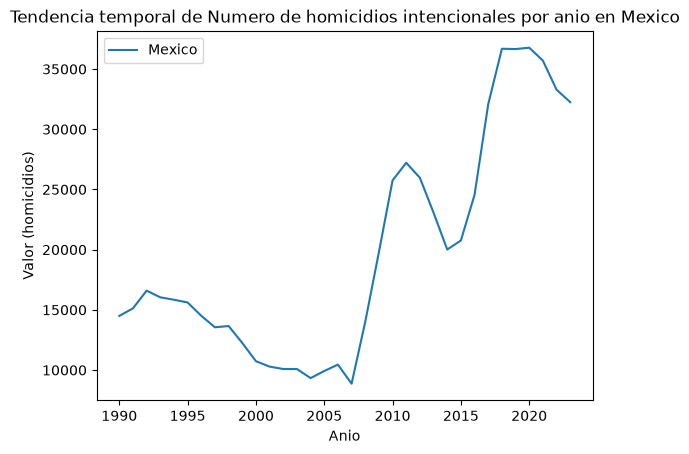

Maximo: 36,773.0 en 2020
Minimo: 8,867.0 en 2007


In [14]:
# Pregunta 5
pais_tendencia = "Mexico"
serie_p5 = (
    df_paises.loc[(df_paises["entity"] == pais_tendencia) & df_paises["valor"].notna(), ["year", "valor"]]
    .sort_values("year")
    .copy()
)
maximo_p5 = serie_p5.loc[serie_p5["valor"].idxmax()]
minimo_p5 = serie_p5.loc[serie_p5["valor"].idxmin()]
pendiente_p5 = np.polyfit(serie_p5["year"], serie_p5["valor"], 1)[0]

plt.plot(serie_p5["year"], serie_p5["valor"], label=pais_tendencia)
plt.title(f"Tendencia temporal de {config['descripcion']} en {pais_tendencia}")
plt.xlabel("Anio")
plt.ylabel(f"Valor ({config['unidad']})")
plt.legend()
plt.show()

print(f"Maximo: {maximo_p5['valor']:,} en {int(maximo_p5['year'])}")
print(f"Minimo: {minimo_p5['valor']:,} en {int(minimo_p5['year'])}")


**Interpretación:**

*A pesar de que se ve un descenso en la cantidad de homicios desde 1992 al 2005 (aproximadamente), y otro desde 2010 a 2015, la tendencia es creciente ya que tomando de referencia el primer año del data frame (1990) y el último registro se puede observar que la cantidad de homicios aumentó más de un 100%*

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [15]:
# Pregunta 6
serie_mexico = (
    df_paises.loc[(df_paises["entity"] == "Mexico") & df_paises["valor"].notna(), ["year", "valor"]]
    .sort_values("year")
    .reset_index(drop=True)
)
primer_dato = serie_mexico.iloc[0]
ultimo_dato = serie_mexico.iloc[-1]
cambio_porcentual = ((ultimo_dato["valor"] - primer_dato["valor"]) / primer_dato["valor"]) * 100

print(f"Primer dato: {int(primer_dato['year'])} = {primer_dato['valor']:,}")
print(f"Ultimo dato: {int(ultimo_dato['year'])} = {ultimo_dato['valor']:,}")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")

Primer dato: 1990 = 14,493.0
Ultimo dato: 2023 = 32,252.0
Cambio porcentual: 122.54%


**Interpretación:**

*Se ha tenido un incremento relativo. En México el tema del narcotrafico probablemente sea la principal razón del aumento de homicidios, además coincide con el inicio de la "guerra contra el narcotráfico" a finales del 2006; desde 2007 se muestra como va aumentando la cantidad de homicidios. También puedes influir otros aspectos políticos y sociales.*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [16]:
# Pregunta 7
anio_reciente_p7 = df_paises.loc[df_paises["valor"].notna(), "year"].max()
valores_p7 = (
    df_paises.loc[(df_paises["year"] == anio_reciente_p7) & df_paises["valor"].notna(), "valor"]
    .to_numpy()
)

media_p7 = np.mean(valores_p7)
mediana_p7 = np.median(valores_p7)
desviacion_p7 = np.std(valores_p7)

print(f"Anio analizado: {anio_reciente_p7}")
print(f"Media: {media_p7:,.2f}")
print(f"Mediana: {mediana_p7:,.2f}")
print(f"Desviacion estandar: {desviacion_p7:,.2f}")


Anio analizado: 2024
Media: 1,402.50
Mediana: 209.50
Desviacion estandar: 3,319.74


**Interpretación:**

*Para el año más reciente disponible, la media es mayor que la mediana, lo que indica que algunos paises con cantidades muy altas de homicidios elevan el promedio. La desviación estándar muestra una alta dispersión entre paises, por lo que los valores no se concentran alrededor de un nivel similar*

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

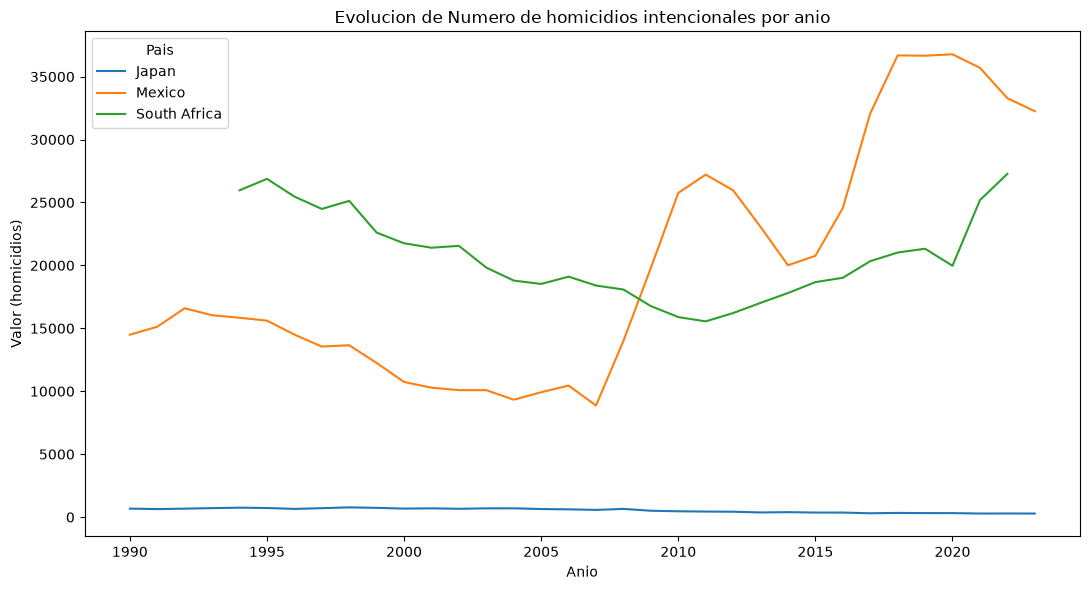

In [17]:
# Pregunta 8
paises_grafica = ["Mexico", "Japan", "South Africa"]
datos_p8 = df_paises[df_paises["entity"].isin(paises_grafica)].dropna(subset=["valor"])

plt.figure(figsize=(11, 6))
for pais, serie in datos_p8.groupby("entity"):
    serie = serie.sort_values("year")
    plt.plot(serie["year"], serie["valor"], label=pais)

plt.title(f"Evolucion de {config['descripcion']}")
plt.xlabel("Anio")
plt.ylabel(f"Valor ({config['unidad']})")
plt.legend(title="Pais")
plt.tight_layout()
plt.show()


**Interpretación:**

*A diferencia de México y Brasil, Japon mantiene una cantidad de homicidios muy estable. México presenta un aumento como ya se analizó anteriormente. Podemos ver como desde 2008 aproximadamente México superó en cantidad de homicios a Brasil, antes de esto presentaba una mayor cantidad.*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

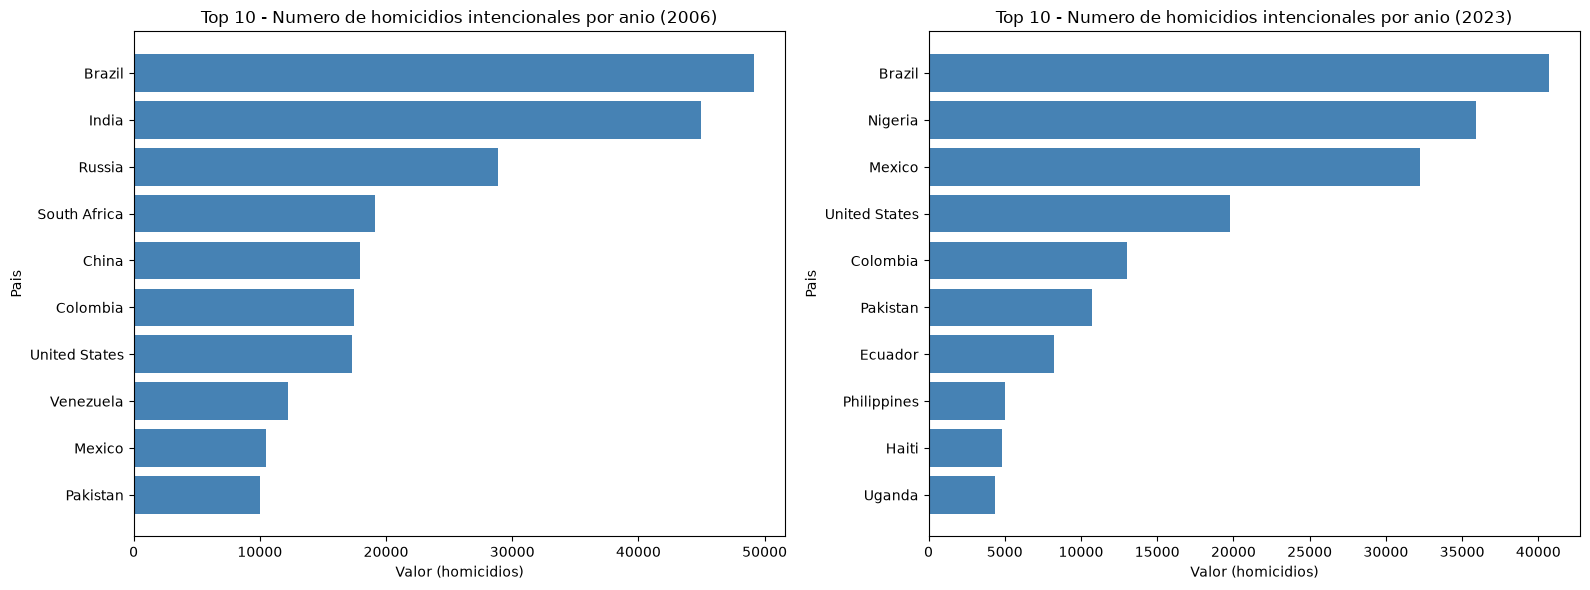

,entity,valor
3319,Pakistan,10048.0
2734,Mexico,10452.0
4773,Venezuela,12257.0
4651,United States,17309.0
985,Colombia,17479.0
954,China,17973.0
4062,South Africa,19106.0
3669,Russia,28844.0
2023,India,44961.0
705,Brazil,49165.0


,entity,valor
4569,Uganda,4366.0
1879,Haiti,4789.0
3467,Philippines,4995.0
1340,Ecuador,8221.0
3336,Pakistan,10729.0
1002,Colombia,13035.0
4668,United States,19796.0
2751,Mexico,32252.0
3095,Nigeria,35884.0
722,Brazil,40698.0


In [18]:
# Pregunta 9
# Tu codigo aqui
anio_nacimiento = 2006
anio_comparacion = 2023

top_nacimiento = (
    df_paises.loc[(df_paises["year"] == anio_nacimiento) & df_paises["valor"].notna()]
    .nlargest(10, "valor")
    .sort_values("valor", ascending=True)
)
top_2023 = (
    df_paises.loc[(df_paises["year"] == anio_comparacion) & df_paises["valor"].notna()]
    .nlargest(10, "valor")
    .sort_values("valor", ascending=True)
)

fig, ejes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)
for eje, datos, anio in zip(ejes, [top_nacimiento, top_2023], [anio_nacimiento, anio_comparacion]):
    eje.barh(datos["entity"], datos["valor"], color="steelblue")
    eje.set_title(f"Top 10 - {config['descripcion']} ({anio})")
    eje.set_xlabel(f"Valor ({config['unidad']})")
    eje.set_ylabel("Pais")

plt.tight_layout()
plt.show()

display(top_nacimiento[["entity", "valor"]])
display(top_2023[["entity", "valor"]])


**Interpretación:**

*Algunos paises se mantienen entre los valores más altos, mientras que otros aumental o disminuten su posición en el ranking. Esta posición en el top puede relacionarse a las condiciones de seguridad y con el tamaño de la población en cada pais.*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*EL dataset permitió analizar la evolucion anual de la cantidad de homicios en distintos paises. Se obersvan diferencias imporantes entre paises, ya que algunos concentran cantidades mucho mayores que otros. Para México, los valores no se mantienen constantes y podemos relacionarlos a distintos eventos o cambios (principalmente políticos) en el país. Las comparaciones entre grupos y rankings permiten identificar que paises tienen los valores más altos en años específcios. Hay que tomar en cuenta que pueden existir años o paises sin información completa. Seria interesante para el análisis hacerlo por tasa de homicidio, en relación a la cantidad de habitantes, ya que por ejemplo en un pais con muy pocos habitantes una cantidad aparentemente baja de homicidios podría ser bastante más alarmente si se tomara en cuenta que por ejemplo el 5% de la población es victima de homicidio pero un pais con un número mayor de valor absoluto de homicidios solo corresponde a un 0.5%.*

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
